In [661]:
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import PowerTransformer
# from sklearn.linear_model import LogisticRegression

# # Sayısal kolonlar için pipeline
# num_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),   # NaN doldurma
#     ("scaler", PowerTransformer(method="yeo-johnson"))  # Dönüşüm
# ])

# # Kategorik kolonlar için pipeline
# from sklearn.preprocessing import OneHotEncoder
# cat_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),  # NaN doldurma
#     ("encoder", OneHotEncoder(handle_unknown="ignore"))    # One-hot encode
# ])

# # Sayısal ve kategorik pipeline’ları birleştirme
# from sklearn.compose import ColumnTransformer

# preprocessor = ColumnTransformer([
#     ("num", num_pipeline, numerical_features),   # numerical_features: sayısal kolon listesi
#     ("cat", cat_pipeline, categorical_features)  # categorical_features: kategorik kolon listesi
# ])

# # Final pipeline (ön işleme + model)
# pipe = Pipeline([
#     ("preprocessor", preprocessor),
#     ("model", LogisticRegression(random_state=42))
# ])

# # Eğitme
# pipe.fit(X_train, y_train)

# # Tahmin
# y_pred = pipe.predict(X_test)

# # Skor
# print(pipe.score(X_test, y_test))


In [662]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [663]:
df = df.drop(["id"], axis=1)
# ;
numerical_features = [feature for feature in df.columns if df[feature].dtypes != "O" and feature != "num"]
categorical_features = [feature for feature in df.columns if df[feature].dtypes=="O" and feature != "num"]
numerical_features, categorical_features

(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'],
 ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'])

In [664]:
df.isnull().sum().sort_values(ascending=False)

ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
age           0
sex           0
dataset       0
cp            0
num           0
dtype: int64

In [665]:
discrete_numerical_features = [feature for feature in numerical_features if len(df[feature].unique())<25]
discrete_numerical_features

['ca']

In [666]:
continuous_numerical_features =  [feature for feature in numerical_features if feature not in discrete_numerical_features]
continuous_numerical_features

['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [667]:
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer()

# Fit the imputer on trestbps column
imputer1.fit(df[['trestbps']])

# Transform the data
df['trestbps'] = imputer1.transform(df[['trestbps']])

In [668]:
from sklearn.impute import SimpleImputer
# create an object of iterative imputer 
imputer2 = SimpleImputer()

# fit transform on ca,oldpeak, thal,chol and thalch columns
df['ca'] = imputer2.fit_transform(df[['ca']])
df['oldpeak']= imputer2.fit_transform(df[['oldpeak']])
df['chol'] = imputer2.fit_transform(df[['chol']])
df['thalch'] = imputer2.fit_transform(df[['thalch']])

In [669]:
df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending=False)

thal       486
slope      309
fbs         90
exang       55
restecg      2
dtype: int64

In [670]:
missing__categorical_cols = df.isnull().sum()[df.isnull().sum()>0].index.tolist()
missing__categorical_cols

['fbs', 'restecg', 'exang', 'slope', 'thal']

In [671]:
for col in ['fbs', 'exang', 'restecg']:
    col_mode = df[col].mode()[0]
    print(col_mode)
    df[col] = df[col].fillna(col_mode)
df.isnull().sum()[df.isnull().sum()>0].sort_values(ascending=False)

False
False
normal


C:\Users\atahi\AppData\Local\Temp\ipykernel_6168\327642140.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(col_mode)


thal     486
slope    309
dtype: int64

In [672]:
def cholesterol_group(chol):
    if chol < 200:
        return 0
    elif chol <= 239:
        return 1
    elif chol <= 299:
        return 2
    else:
        return 3

df["chol_group"] = df["chol"].apply(cholesterol_group)

In [673]:
df.drop(['chol'], axis=1, inplace=True)

In [674]:
df.head()

,age,sex,dataset,cp,trestbps,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,chol_group
0,63,Male,Cleveland,typical angina,145.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,1
1,67,Male,Cleveland,asymptomatic,160.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,2
2,67,Male,Cleveland,asymptomatic,120.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,1
3,37,Male,Cleveland,non-anginal,130.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,2
4,41,Female,Cleveland,atypical angina,130.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,1


In [675]:
continuous_numerical_features.remove("chol")

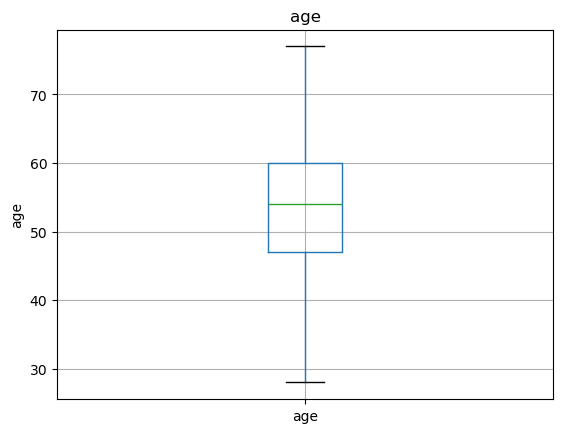

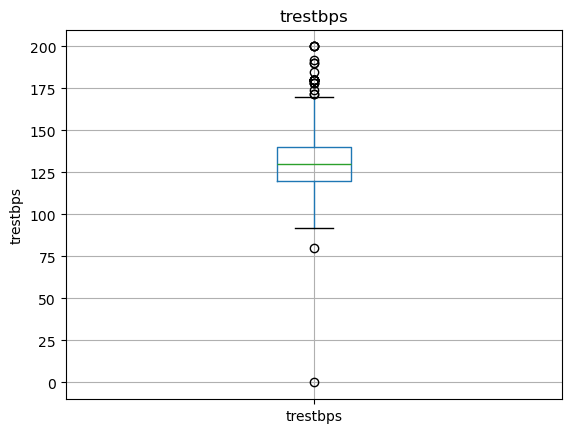

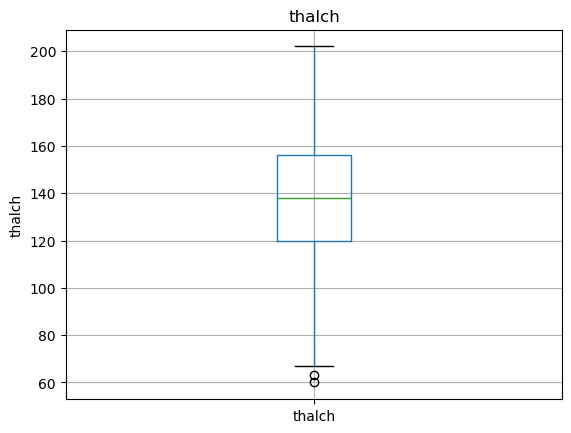

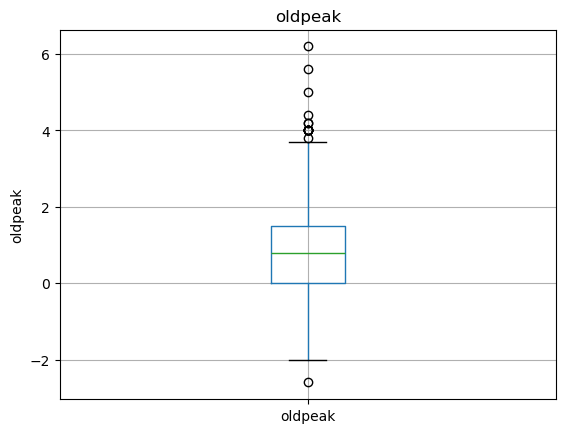

In [676]:
for feature in continuous_numerical_features:
    data = df.copy()
    
    data.boxplot(column=feature)
    plt.ylabel(feature)
    plt.title(feature)
    plt.show()

In [677]:
continuous_numerical_features

['age', 'trestbps', 'thalch', 'oldpeak']

In [678]:
def MinMaxScaler(X):
    return (X - X.min()) / (X.max() - X.min())
def ZScaler(X):
    return (X - np.mean(X)) / np.std(X)

In [679]:
df[continuous_numerical_features] = ZScaler(df[continuous_numerical_features])
df

C:\Users\atahi\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


,age,sex,dataset,cp,trestbps,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,chol_group
0,-1.912714,Male,Cleveland,typical angina,3.470952,True,lv hypertrophy,2.745614,False,-74.740647,downsloping,0.000000,fixed defect,0,1
1,-1.488066,Male,Cleveland,asymptomatic,4.284671,False,lv hypertrophy,1.073960,True,-75.500236,flat,3.000000,normal,2,2
2,-1.488066,Male,Cleveland,asymptomatic,2.114752,False,lv hypertrophy,1.909787,True,-74.455802,flat,2.000000,reversable defect,1,1
3,-4.672928,Male,Cleveland,non-anginal,2.657232,False,normal,4.218260,False,-73.601264,downsloping,0.000000,normal,0,2
4,-4.248280,Female,Cleveland,atypical angina,2.657232,False,lv hypertrophy,3.621241,False,-75.595185,upsloping,0.000000,normal,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,-2.868173,Female,VA Long Beach,asymptomatic,2.494488,True,st-t abnormality,2.904819,False,-76.924466,NaN,0.676375,NaN,1,3
916,-2.018876,Male,VA Long Beach,typical angina,2.772911,False,st-t abnormality,2.249915,False,-76.090069,NaN,0.676375,NaN,0,0
917,-2.762011,Male,VA Long Beach,asymptomatic,2.223248,True,st-t abnormality,0.755550,False,-76.924466,NaN,0.676375,fixed defect,2,1
918,-2.443525,Male,VA Long Beach,asymptomatic,2.772911,True,lv hypertrophy,2.249915,False,-76.090069,NaN,0.676375,NaN,0,3


## categorical features 

nominal veri -> one hot encoding

ordinal veri -> label encoding

------
sex:  ['Male' 'Female']

dataset:  ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

cp:  ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs:  [True False nan]

restecg:  ['lv hypertrophy' 'normal' 'st-t abnormality' nan]

exang:  [False True nan]

slope:  ['downsloping' 'flat' 'upsloping' nan]

thal:  ['fixed defect' 'normal' 'reversable defect' nan]


In [681]:
df_encoded = pd.get_dummies(df, columns=['dataset', 'cp', 'slope', 'thal'], dtype=int)
#df_encoded = pd.get_dummies(df, columns=['dataset', 'cp', 'slope', 'thal'], dtype=int, drop_first=True)

In [682]:
restecg_val = df['restecg'].unique().tolist()
print(restecg_val)

for i, val in enumerate(restecg_val):
    df_encoded['restecg'] = df_encoded['restecg'].replace(val, i)

['lv hypertrophy', 'normal', 'st-t abnormality']


C:\Users\atahi\AppData\Local\Temp\ipykernel_6168\1918138821.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_encoded['restecg'] = df_encoded['restecg'].replace(val, i)


In [683]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ['sex', 'fbs', 'exang']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [684]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_encoded.drop(["num"], axis=1), df_encoded["num"], test_size=0.1, random_state=42)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model.score(X_test, y_test)

C:\Users\atahi\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.4673913043478261

In [685]:
import numpy as np

def Z(X, w, b):
    return np.dot(X, w) + b

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(y, yhat):
    m = y.shape[0]
    return - (1/m) * np.sum(y * np.log(yhat + 1e-15))

def gradient_descent(w, b, X, y, yhat, m, learning_rate=0.05):
    dLdw = (1/m) * np.dot(X.T, (yhat - y))
    dLdb = (1/m) * np.sum(yhat - y, axis=0, keepdims=True)
    w = w - learning_rate * dLdw
    b = b - learning_rate * dLdb
    return w, b

# initialize
m, n = X_train.shape
w = 0.01 * np.random.randn(n, 5)
b = np.zeros((1, 5))

num_classes = 5
y_train_onehot = np.eye(num_classes)[y_train]

epochs = 1000
learning_rate = 0.001

costs = []

for epoch in range(epochs):
    # forward
    Z_train = Z(X_train, w, b)
    yhat = softmax(Z_train)
    loss = cross_entropy(y_train_onehot, yhat)
    
    # backward
    w, b = gradient_descent(w, b, X_train, y_train_onehot, yhat, m, learning_rate)
    
    # her 50 epoch'ta loss yazdır
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
    costs.append(loss)


Epoch 0, Loss: 1.9448
Epoch 50, Loss: 1.3628
Epoch 100, Loss: 1.3542
Epoch 150, Loss: 1.3456
Epoch 200, Loss: 1.3370
Epoch 250, Loss: 1.3285
Epoch 300, Loss: 1.3200
Epoch 350, Loss: 1.3116
Epoch 400, Loss: 1.3032
Epoch 450, Loss: 1.2949
Epoch 500, Loss: 1.2866
Epoch 550, Loss: 1.2785
Epoch 600, Loss: 1.2704
Epoch 650, Loss: 1.2624
Epoch 700, Loss: 1.2545
Epoch 750, Loss: 1.2467
Epoch 800, Loss: 1.2390
Epoch 850, Loss: 1.2315
Epoch 900, Loss: 1.2240
Epoch 950, Loss: 1.2167


In [686]:
def predict(X, w, b):
    yhat = softmax(Z(X, w, b))
    return np.argmax(yhat, axis=1) 
y_pred = predict(X_train, w, b)
y_true = np.argmax(y_train_onehot, axis=1)   # one-hot → sınıf index
np.mean(y_pred == y_true)

0.5700483091787439

In [687]:
continuous_numerical_features

['age', 'trestbps', 'thalch', 'oldpeak']

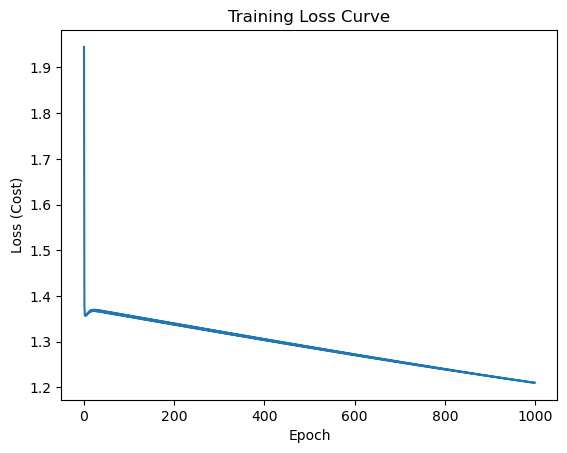

In [688]:
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("Loss (Cost)")
plt.title("Training Loss Curve")
plt.show()